**Notebook:** Overall Performance Comparison                             
**Architectures Compared:** 6 perception architectures                           
**Task:** Cross-Architecture Performance Evaluation                           
**Dataset:** nuScenes-mini                          
**Metrics:** IoU, Precision, Recall, and F1-score

## Objective

This notebook aggregates the saved evaluation summaries for all six perception architectures and produces a unified comparison of:

- Intersection over Union (IoU)
- Precision
- Recall
- F1-score

The notebook reads the existing model summary CSV files from the `reports/` directory. It does **not** retrain models or rerun inference, ensuring that the comparison uses the exact metrics already produced by the individual experiment notebooks.

## Compared Architectures

1. RGB Baseline
2. LiDAR BEV Baseline
3. Multimodal Fusion
4. Multimodal Fusion + CBAM
5. Multimodal Cross-Attention Fusion
6. Multimodal Hybrid Cross-Attention

## Outputs

- Combined performance summary table
- Grouped performance comparison chart
- Exported comparison CSV in `reports/`
- Exported figure in `assets/`

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
assets	     colab_packages  deployment  nuscenes  results
checkpoints  data	     notebooks	 reports   src


In [ ]:
# ============================================================
# Imports and Project Configuration
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Project directories
# ------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception")

REPORTS_DIR = PROJECT_ROOT / "reports"
ASSETS_DIR = PROJECT_ROOT / "assets"

ASSETS_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Matplotlib defaults
# ------------------------------------------------------------

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


# ------------------------------------------------------------
# Utility function
# ------------------------------------------------------------

def save_figure(
    figure,
    filename: str,
) -> None:
    """
    Save a matplotlib figure to the assets directory.
    """

    output_path = ASSETS_DIR / filename

    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(f"Saved figure to:\n{output_path}")


print(f"Project Root : {PROJECT_ROOT}")
print(f"Reports      : {REPORTS_DIR}")
print(f"Assets       : {ASSETS_DIR}")

Project Root : /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
Reports      : /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/reports
Assets       : /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/assets


In [ ]:
# ============================================================
# Summary CSV Files
# ============================================================

summary_files = {
    "RGB Baseline":
        REPORTS_DIR / "rgb_baseline_summary.csv",

    "LiDAR BEV Baseline":
        REPORTS_DIR / "lidar_baseline_summary.csv",

    "Multimodal Fusion":
        REPORTS_DIR / "fusion_baseline_summary.csv",

    "Fusion + CBAM":
        REPORTS_DIR / "fusion___cbam_summary.csv",

    "Cross-Attention Fusion":
        REPORTS_DIR /
        "fusioncrossattentionmodel_rgb___lidar___imu_summary.csv",

    "Hybrid Cross-Attention":
        REPORTS_DIR /
        "fusionhybridxattentionmodel_rgb___lidar___imu_summary.csv",
}


print("Summary CSV Files")
print("-" * 60)

for model_name, file_path in summary_files.items():
    status = "✓ Found" if file_path.exists() else "✗ Missing"
    print(f"{status:10} {model_name}")
    print(f"           {file_path}\n")

Summary CSV Files
------------------------------------------------------------
✓ Found    RGB Baseline
           /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/reports/rgb_baseline_summary.csv

✓ Found    LiDAR BEV Baseline
           /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/reports/lidar_baseline_summary.csv

✓ Found    Multimodal Fusion
           /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/reports/fusion_baseline_summary.csv

✓ Found    Fusion + CBAM
           /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/reports/fusion___cbam_summary.csv

✓ Found    Cross-Attention Fusion
           /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/reports/fusioncrossattentionmodel_rgb___lidar___imu_summary.csv

✓ Found    Hybrid Cross-Attention
           /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/reports/fusionhybridxattenti

In [ ]:
# ============================================================
# Load Summary CSV Files
# ============================================================

summary_tables = {}

for model_name, csv_file in summary_files.items():

    df = pd.read_csv(csv_file)

    summary_tables[model_name] = df

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    display(df)

RGB Baseline


,Metric,Value
0,Mean IoU,0.290864
1,Mean Precision,0.517523
2,Mean Recall,0.401921
3,Mean F1,0.447905


LiDAR BEV Baseline


,Metric,Value
0,Mean IoU,0.557718
1,Mean Precision,0.679294
2,Mean Recall,0.756177
3,Mean F1 Score,0.715520


Multimodal Fusion


...

,Metric,Value
0,Mean IoU,0.559150
1,Mean Precision,0.611607
2,Mean Recall,0.866677
3,Mean F1 Score,0.716962


Cross-Attention Fusion


,Metric,Value
0,Mean IoU,0.300017
1,Mean Precision,0.379552
2,Mean Recall,0.611099
3,Mean F1,0.460877


Hybrid Cross-Attention


,Metric,Value
0,Mean IoU,0.601722
1,Mean Precision,0.649660
2,Mean Recall,0.890643
3,Mean F1,0.751087


In [ ]:
# ============================================================
# Build Combined Performance Table
# ============================================================

performance_rows = []

for model_name, df in summary_tables.items():

    metrics = dict(zip(df["Metric"], df["Value"]))

    performance_rows.append({
        "Model": model_name,
        "IoU": metrics["Mean IoU"],
        "Precision": metrics["Mean Precision"],
        "Recall": metrics["Mean Recall"],
        "F1": metrics.get("Mean F1", metrics.get("Mean F1 Score"))
    })

performance_df = pd.DataFrame(performance_rows)

performance_df = performance_df.round(4)

performance_df

,Model,IoU,Precision,Recall,F1
0,RGB Baseline,0.2909,0.5175,0.4019,0.4479
1,LiDAR BEV Baseline,0.5577,0.6793,0.7562,0.7155
2,Multimodal Fusion,0.7150,0.7847,0.8887,0.8333
3,Fusion + CBAM,0.5592,0.6116,0.8667,0.7170
4,Cross-Attention Fusion,0.3000,0.3796,0.6111,0.4609
5,Hybrid Cross-Attention,0.6017,0.6497,0.8906,0.7511


In [ ]:
# ============================================================
# Export Combined Performance Table
# ============================================================

output_csv = REPORTS_DIR / "performance_comparison.csv"

performance_df.to_csv(
    output_csv,
    index=False,
)

print(f"Performance comparison saved to:\n{output_csv}")

display(performance_df)

Performance comparison saved to:
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/reports/performance_comparison.csv


,Model,IoU,Precision,Recall,F1
0,RGB Baseline,0.2909,0.5175,0.4019,0.4479
1,LiDAR BEV Baseline,0.5577,0.6793,0.7562,0.7155
2,Multimodal Fusion,0.7150,0.7847,0.8887,0.8333
3,Fusion + CBAM,0.5592,0.6116,0.8667,0.7170
4,Cross-Attention Fusion,0.3000,0.3796,0.6111,0.4609
5,Hybrid Cross-Attention,0.6017,0.6497,0.8906,0.7511


Saved figure to:
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/assets/performance_comparison.png


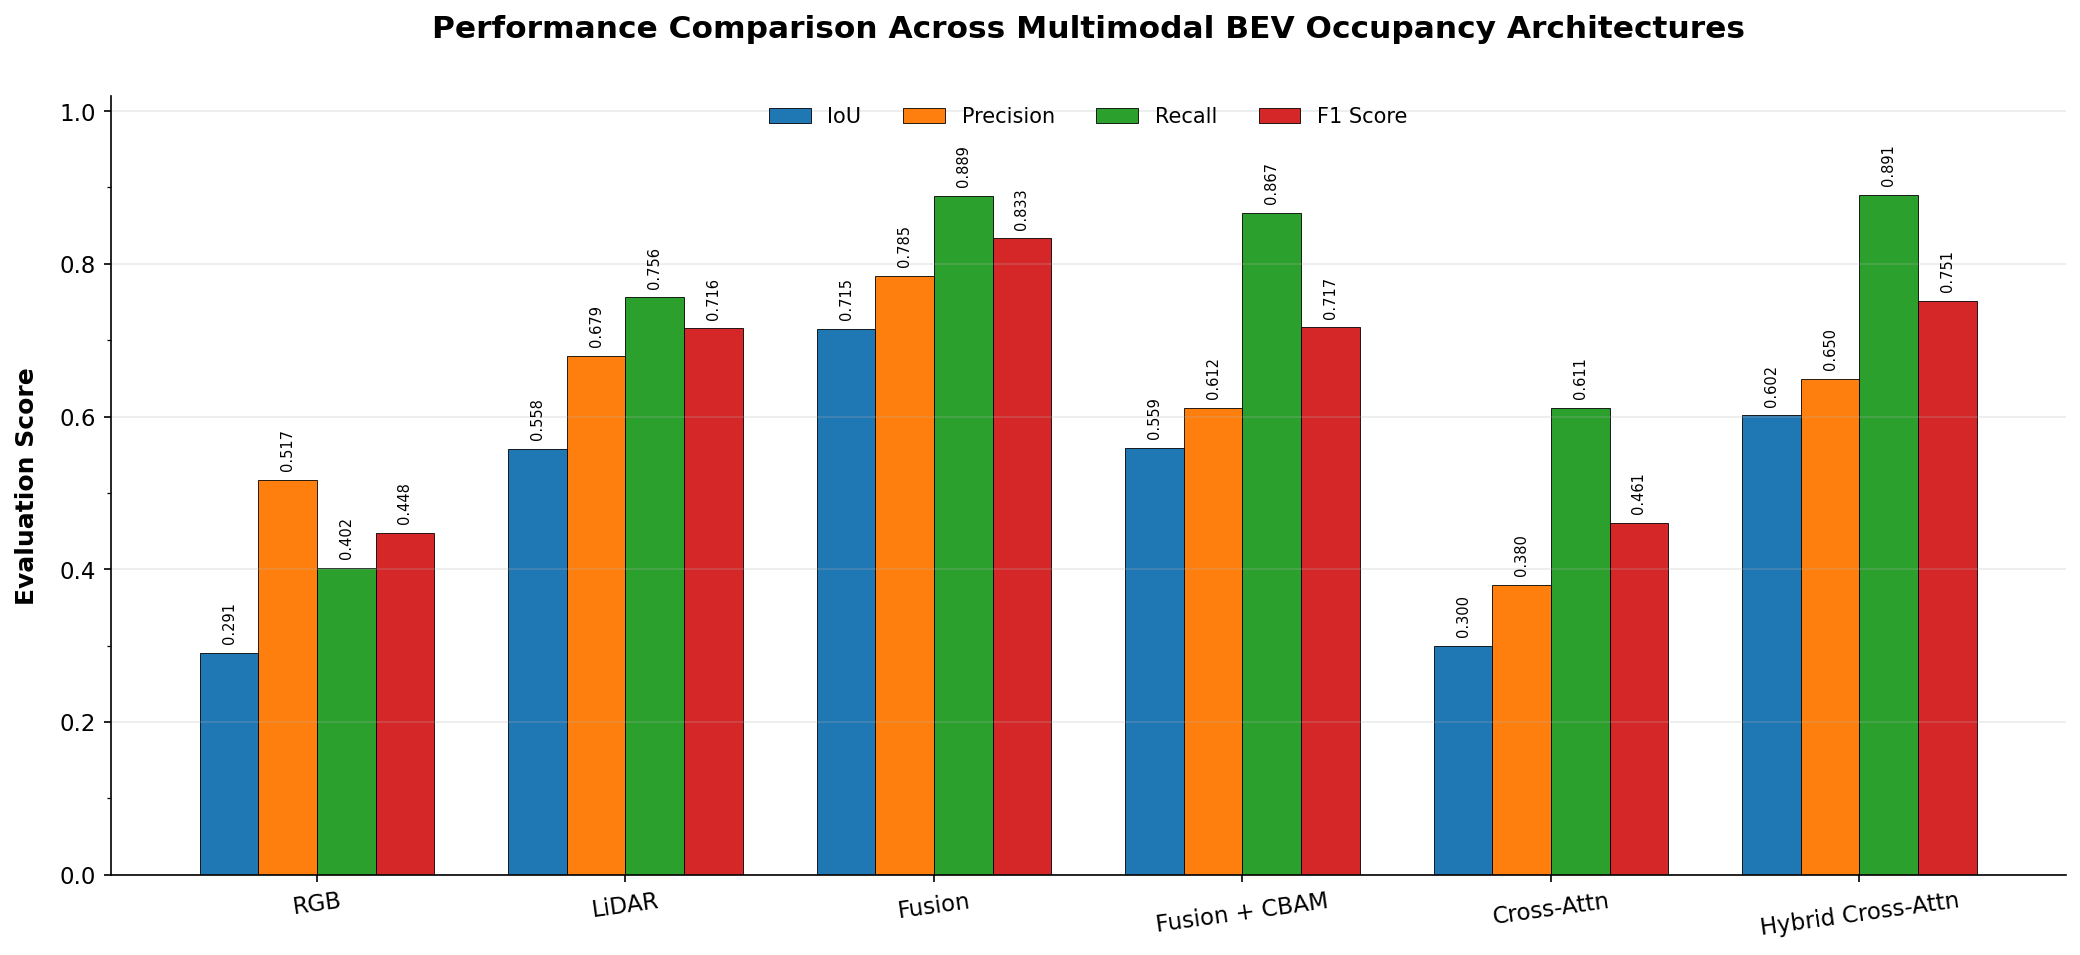

In [ ]:
# ============================================================
# Overall Performance Comparison
# ============================================================
from matplotlib.ticker import MultipleLocator


metrics = [
    "IoU",
    "Precision",
    "Recall",
    "F1 Score",
]

# Short display labels for a cleaner figure.
display_labels = {
    "RGB Baseline": "RGB",
    "LiDAR BEV Baseline": "LiDAR",
    "Multimodal Fusion": "Fusion",
    "Fusion + CBAM": "Fusion + CBAM",
    "Cross-Attention Fusion": "Cross-Attn",
    "Hybrid Cross-Attention": "Hybrid Cross-Attn",
}

performance_df.rename(columns={"F1": "F1 Score"}, inplace=True)

model_labels = [
    display_labels.get(model_name, model_name)
    for model_name in performance_df["Model"]
]

x = np.arange(len(performance_df))
width = 0.19

fig, ax = plt.subplots(figsize=(14, 6.5))

ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

for i, metric in enumerate(metrics):

    bar_positions = x + (i - 1.5) * width

    bars = ax.bar(
        bar_positions,
        performance_df[metric],
        width=width,
        label=metric,
        edgecolor="black",
        linewidth=0.4,
    )

    # Add numeric value labels above each bar.
    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.012,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    model_labels,
    rotation=8,
    ha="center",
)

ax.set_xlabel("")

ax.set_ylabel(
    "Evaluation Score",
    fontweight="bold",
    labelpad=10,
)

ax.set_ylim(0.0, 1.02)

ax.set_title(
    "Performance Comparison Across Multimodal BEV Occupancy Architectures",
    pad=28,
    fontweight="bold",
)


# ------------------------------------------------------------
# Grid and visual cleanup
# ------------------------------------------------------------

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.grid(
    axis="x",
    visible=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4,
    frameon=False,
)


# ------------------------------------------------------------
# Layout, export, and display
# ------------------------------------------------------------

fig.tight_layout()

save_figure(
    fig,
    "performance_comparison.png",
)

plt.show()

Deployment latency comparison

,Model,GPU Latency (ms)
0,Multimodal Fusion,2.56
1,Hybrid Cross-Attention,3.87


Saved figure to:
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/assets/latency_plot.png


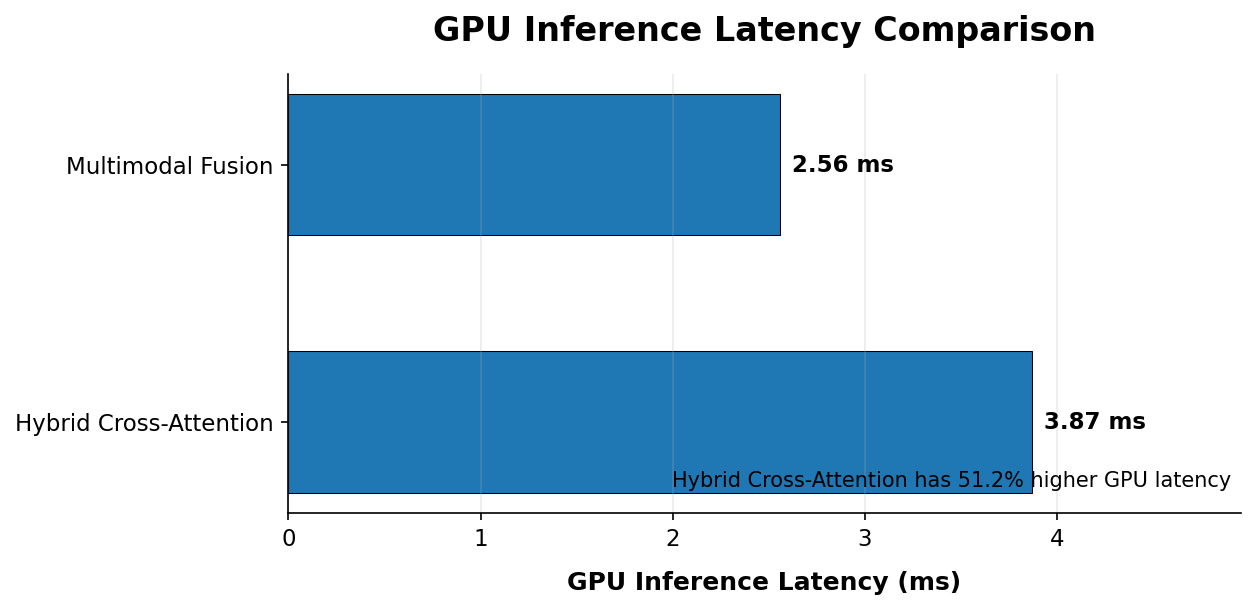

In [ ]:
# ============================================================
# GPU Inference Latency Comparison
# ============================================================

# ------------------------------------------------------------
# Deployment benchmark results
# ------------------------------------------------------------

deployment_df = pd.DataFrame(
    {
        "Model": [
            "Multimodal Fusion",
            "Hybrid Cross-Attention",
        ],
        "GPU Latency (ms)": [
            2.56,
            3.87,
        ],
    }
)

display(deployment_df)


# ------------------------------------------------------------
# Derived comparison
# ------------------------------------------------------------

fusion_latency = deployment_df.loc[
    deployment_df["Model"] == "Multimodal Fusion",
    "GPU Latency (ms)",
].iloc[0]

hybrid_latency = deployment_df.loc[
    deployment_df["Model"] == "Hybrid Cross-Attention",
    "GPU Latency (ms)",
].iloc[0]

relative_increase = (
    (hybrid_latency - fusion_latency)
    / fusion_latency
    * 100.0
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.5, 4.2),
)

bars = ax.barh(
    deployment_df["Model"],
    deployment_df["GPU Latency (ms)"],
    height=0.55,
    edgecolor="black",
    linewidth=0.5,
)


# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for bar in bars:

    latency = bar.get_width()

    ax.text(
        latency + 0.06,
        bar.get_y() + bar.get_height() / 2,
        f"{latency:.2f} ms",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
    )


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_xlabel(
    "GPU Inference Latency (ms)",
    fontsize=12,
    fontweight="bold",
    labelpad=10,
)

ax.set_title(
    "GPU Inference Latency Comparison",
    fontsize=16,
    fontweight="bold",
    pad=16,
)

# Place the faster model at the top.
ax.invert_yaxis()

ax.set_xlim(
    0,
    deployment_df["GPU Latency (ms)"].max() * 1.28,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.grid(
    axis="y",
    visible=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# Engineering takeaway
# ------------------------------------------------------------

ax.text(
    0.99,
    0.05,
    (
        f"Hybrid Cross-Attention has "
        f"{relative_increase:.1f}% higher GPU latency"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
)


# ------------------------------------------------------------
# Layout, export, and display
# ------------------------------------------------------------

fig.tight_layout()

save_figure(
    fig,
    "latency_plot.png",
)

plt.show()

,Model,GPU Latency (ms)
0,Fusion,2.56
1,Hybrid Cross-Attn,3.87


Saved figure to:
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/assets/latency_plot.png


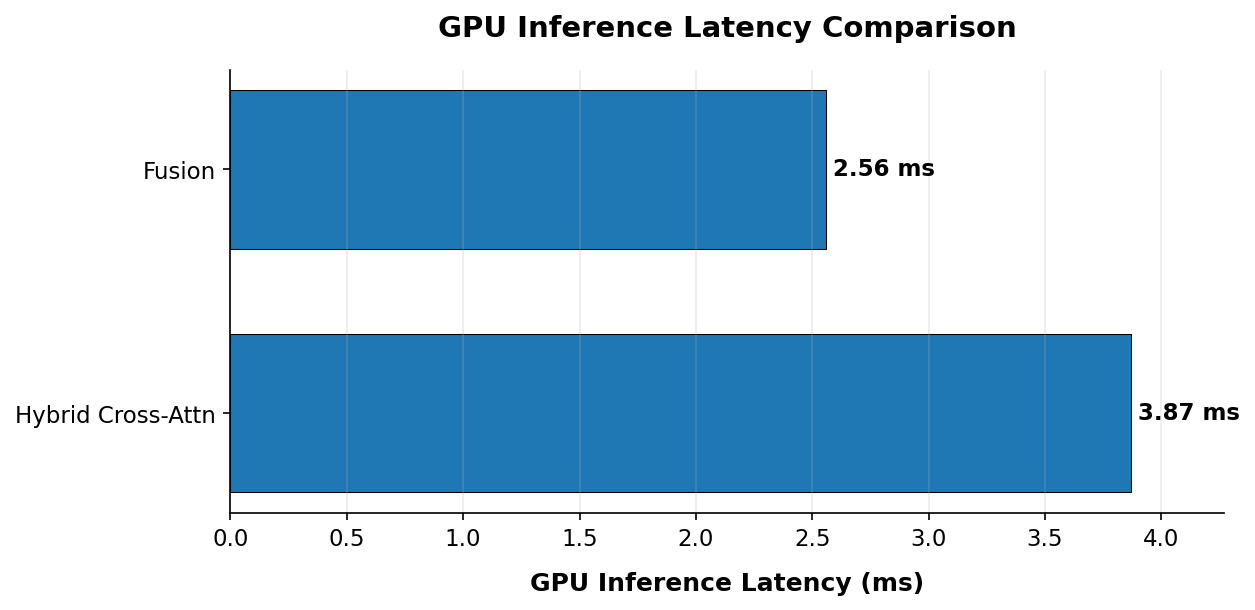

In [ ]:
# ============================================================
# GPU Inference Latency Comparison
# ============================================================

# ------------------------------------------------------------
# Deployment benchmark results
# ------------------------------------------------------------

deployment_df = pd.DataFrame(
    {
        "Model": [
            "Fusion",
            "Hybrid Cross-Attn",
        ],
        "GPU Latency (ms)": [
            2.56,
            3.87,
        ],
    }
)

display(deployment_df)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.5, 4.2),
)

bars = ax.barh(
    deployment_df["Model"],
    deployment_df["GPU Latency (ms)"],
    height=0.65,
    edgecolor="black",
    linewidth=0.5,
)


# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for bar in bars:

    latency = bar.get_width()

    ax.text(
        latency + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{latency:.2f} ms",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
    )


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_xlabel(
    "GPU Inference Latency (ms)",
    fontsize=12,
    fontweight="bold",
    labelpad=10,
)

ax.set_title(
    "GPU Inference Latency Comparison",
    fontsize=14,
    fontweight="bold",
    pad=16,
)

# Place the faster model at the top.
ax.invert_yaxis()

# Keep enough room for the value label beside the longest bar.
ax.set_xlim(
    0,
    deployment_df["GPU Latency (ms)"].max() + 0.40,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.grid(
    axis="y",
    visible=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# Layout, export, and display
# ------------------------------------------------------------

fig.tight_layout()

save_figure(
    fig,
    "latency_plot.png",
)

plt.show()